# Pick Score

The introduction and implementations of Pick Score.

Written by yuanjk0921@outlook.com

Updated on March 6, 2025

**Contents**
- Pick Score
- PyTorch Implementations

**References**

- [**Pick-a-Pic: An Open Dataset of User Preferences for Text-to-Image Generation** *(NeurIPS 2023)*](https://arxiv.org/pdf/2305.01569): The paper which proposes the Pick Score.

## Pick Score

It trains a CLIP (Huge)-based model for image generation evaluation.

To perform user preference contrastive training (like CLIP), it collects preference image pairs by requiring users to annotate on a web app.

## PyTorch Implementation

In [ ]:
## --------------------------------------------------------------------------------
## Prepare data
## --------------------------------------------------------------------------------
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, image_paths, prompts, image_size):
        self.image_paths = image_paths
        self.prompts = prompts
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        file_path = self.image_paths[index]
        image = self.transform(Image.open(file_path))
        prompt = self.prompts[index]
        return image, prompt, file_path

image_paths = ["0.png"] * 6
image_paths += ["1.png"] * 6
image_paths = image_paths + ["random_noise.png"] * 2

## Save a noise image
noise = np.random.randint(0, 256, (3, 224, 224), dtype=np.uint8)
image = Image.fromarray(noise, mode='RGB')
image.save("random_noise.png")

prompts = [
    "a bench and a bird",
    "a bench and a bowl",
    "a bowl and a bench",
    "a blue bench and a green bowl",
    "a green bench and a blue bowl",
    "a green bench and a green bowl",
    "two bears",
    "a bear and a bear",
    "a bear and a beer",
    "two bears are reading books",
    "two bears are reading some books",
    "three bears are reading books",
    "two bears",
    "a bear and a bear"
]

dataset = ImageDataset(image_paths=image_paths, prompts=prompts, image_size=256)
dataloader = DataLoader(dataset=dataset, batch_size=6, shuffle=False)

In [ ]:
## --------------------------------------------------------------------------------
## Load model
## --------------------------------------------------------------------------------
import torch
from transformers import AutoModel, AutoProcessor

device = "cuda"

processor_path = "pickscore_proceesor/models--laion--CLIP-ViT-H-14-laion2B-s32B-b79K/snapshots/1c2b8495b28150b8a4922ee1c8edee224c284c0c"
processor = AutoProcessor.from_pretrained(processor_path)

model_path = "PickScore_v1/snapshots/a4e4367c6dfa7288a00c550414478f865b875800"
model = AutoModel.from_pretrained(model_path).eval().to(device)

class PickScore:
    def __init__(self, processor, model, device="cuda"):
        self.processor = processor
        self.model = model
        self.device = device
        
    def get_score(self, prompts, images):
        image_inputs = self.processor(
            images=images,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt",
        ).to(self.device)

        text_inputs = self.processor(
            text=prompts,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt",
        ).to(self.device)

        image_embs = self.model.get_image_features(**image_inputs)
        image_embs = image_embs / torch.norm(image_embs, dim=-1, keepdim=True)

        text_embs = self.model.get_text_features(**text_inputs)
        text_embs = text_embs / torch.norm(text_embs, dim=-1, keepdim=True)

        scores = self.model.logit_scale.exp() * (text_embs * image_embs).sum(dim=-1)
    
        return scores.cpu().tolist()

pick_score = PickScore(processor=processor, model=model, device=device)

Unused or unrecognized kwargs: max_length, padding, truncation.


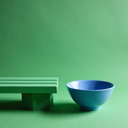

Unused or unrecognized kwargs: max_length, padding, truncation.


=> prompt: a bench and a bird, Score: 18.51179313659668
=> prompt: a bench and a bowl, Score: 18.64800453186035
=> prompt: a bowl and a bench, Score: 19.390104293823242
=> prompt: a blue bench and a green bowl, Score: 19.075462341308594
=> prompt: a green bench and a blue bowl, Score: 18.904420852661133
=> prompt: a green bench and a green bowl, Score: 19.584152221679688


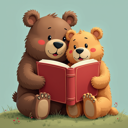

Unused or unrecognized kwargs: max_length, padding, truncation.


=> prompt: two bears, Score: 19.366392135620117
=> prompt: a bear and a bear, Score: 19.652427673339844
=> prompt: a bear and a beer, Score: 18.372190475463867
=> prompt: two bears are reading books, Score: 17.618371963500977
=> prompt: two bears are reading some books, Score: 17.88182258605957
=> prompt: three bears are reading books, Score: 17.573204040527344


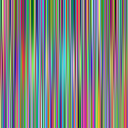

=> prompt: two bears, Score: 20.721467971801758
=> prompt: a bear and a bear, Score: 20.872007369995117


In [6]:
## --------------------------------------------------------------------------------
## Evaluate
## --------------------------------------------------------------------------------
import torch.nn.functional as F

for idx, (images, prompts, file_paths) in enumerate(dataloader):
    scores = pick_score.get_score(prompts, images)
    
    ## Show results
    image = Image.open(file_paths[0]).resize((128, 128))
    display(image)
    for prompt, score in zip(prompts, scores):
        print(f"=> prompt: {prompt}, Score: {score}")

**Observations:**

- It can not even identify <font color=red>random noise</font>.
- It may have good image aesthetics evaluation ability, but can not identify <font color=red>semantic inconsistencies</font>.